In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv('memory_charts_batch_limit.csv')

In [116]:
def get_gradient(df):
    x = df.copy()
    x['chg_images'] = x['IMAGES'].diff()
    x['chg_peak'] = x['peak'].diff()
    x['mb'] = 1024*(x['chg_peak']/x['chg_images'])

    return x['mb'][-3:].mean().item()


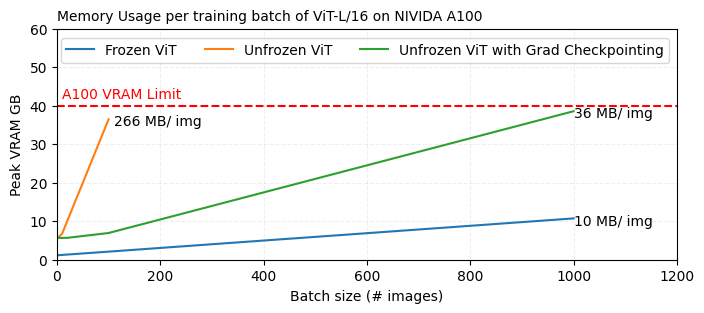

In [ ]:
df_batch_limit = df.groupby(['IMAGES','FROZEN','CHECKPOINTING']).agg({'peak':'max','allocated':'max'}).reset_index()

frozen = df_batch_limit[(df_batch_limit['FROZEN']==True) & (df_batch_limit['CHECKPOINTING']==False)][['IMAGES','peak']]
checkpoints = df_batch_limit[(df_batch_limit['FROZEN']==False) & (df_batch_limit['CHECKPOINTING']==True)][['IMAGES','peak']]
full = df_batch_limit[(df_batch_limit['FROZEN']==False) & (df_batch_limit['CHECKPOINTING']==False)][['IMAGES','peak']]

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(frozen['IMAGES'], frozen['peak'], label='Frozen ViT')
ax.plot(full['IMAGES'], full['peak'], label='Unfrozen ViT')
ax.plot(checkpoints['IMAGES'], checkpoints['peak'], label='Unfrozen ViT with Grad Checkpointing')

ax.text(110,35,f'{get_gradient(full):.0f} MB/ img')
ax.text(1000,9,f'{get_gradient(frozen):.0f} MB/ img')
ax.text(1000,37,f'{get_gradient(checkpoints):.0f} MB/ img')


ax.axhline(40,color='red',linestyle='--')
ax.text(10,42,'A100 VRAM Limit',color='red')

ax.set_xlabel('Batch size (# images)')
ax.set_ylabel('Peak VRAM GB')
ax.set_title('Memory Usage per training batch of ViT-L/16 on NIVIDA A100 ',loc='left',fontsize=10)

ax.set_ylim([0,60])
ax.set_xlim([0,1200])

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
   labels,
    loc='upper left',
    bbox_to_anchor=(0.13, 0.85),
    ncol=len(handles),
    borderaxespad=0.,
    frameon=True
)

ax.grid(True,linestyle='--',alpha=0.2)
plt.savefig("batch_size_limit.png", dpi=300, bbox_inches="tight")
plt.show()